In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

import timm 
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary
from typing import Callable, Tuple, List
from PIL import Image
import itertools
from IPython.display import display

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# DenseNet121
MODEL1_DIR = '/kaggle/input/datasets/xvmhieu/densenet121-5fcv-13'
# MobilenetV2
MODEL2_DIR = '/kaggle/input/datasets/xvmhieu/mobilenetv2-5fcv-13'
# Resnet50
MODEL3_DIR = '/kaggle/input/datasets/xvmhieu/resnet50-5fcv-13'

In [8]:
# Model name
MODEL1_NAME = 'DenseNet121'
MODEL2_NAME = 'MobileNetV2'
MODEL3_NAME = 'ResNet50'


MODEL_ENSEMBLE_NAME = f'tta-{MODEL1_NAME}-{MODEL2_NAME}-{MODEL3_NAME}'

In [9]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 3
DROPOUT_RATE = 0.3
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

In [10]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics (Required for VGG19 weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [11]:
DATASET_CACHE = {}

def get_valid_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> DataLoader:
    """
    Retrieves the validation DataLoader for a specific fold with caching mechanism.
    This function checks if the validation loader for the specified fold `k` is already
    present in the global `DATASET_CACHE`. If found, it returns the cached loader to save memory 
    and processing time. If not, it generates the loader using `get_data_for_fold`, caches it, 
    and then returns it.

    Args:
        k (int): The fold index (e.g., 1 to 5) identifying which subset is used for validation.
        train_dir (str, optional): The root directory path of the training data. 
            Defaults to global TRAIN_DIR.
        batch_size (int, optional): The number of samples per batch to load. 
            Defaults to global BATCH_SIZE.

    Returns:
        DataLoader: The PyTorch DataLoader containing the validation dataset for fold `k`.
    """
    
    # 1. Check if the loader for this fold is already in the cache
    if k in DATASET_CACHE:
        return DATASET_CACHE[k]
    
    # 2. If not in cache, create new loaders
    # Only need val_loader
    _, val_loader = get_data_for_fold(k=k, train_dir=train_dir, batch_size=batch_size)
    
    # 3. Store the newly created validation loader in the cache
    DATASET_CACHE[k] = val_loader

    return val_loader

In [12]:
class DenseNet121(nn.Module):
    """
    DenseNet121-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: DenseNet121 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained DenseNet121
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)

        # DenseNet121 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Unfreezing parameters for base evaluation. 
        for param in self.features.parameters():
            param.requires_grad = True  

        # Define Custom Classifier Head.
        self.in_features = 1024 
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W).
                              Expected standard ImageNet normalization.

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        
        # Feature extraction (Frozen)
        x = self.features(x)
        # The torchvision.models.densenet121 `.features` block ends with a 
        # BatchNorm layer (norm5), which outputs both negative and positive values.
        # We MUST apply ReLU here to zero out negative values (noise/background).
        x = F.relu(x, inplace=True)
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [13]:
def build_densenet121(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> DenseNet121:
    """
    Factory function to instantiate the customized DenseNet121 model for Transfer Learning.

    This function initializes a `DenseNet121` which includes:
    1. A frozen DenseNet121 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (ReLU -> Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        DenseNet121: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """
    
    model = DenseNet121(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [14]:
class MobileNetV2(nn.Module):
    """
    MobileNetV2-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: MobileNetV2 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained MobileNetV2
        weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
        backbone = models.mobilenet_v2(weights=weights)

        # MobileNetV2 .features contains all the convolutional layers (Inverted Residuals)
        self.features = backbone.features

        # Unfreeze ALL
        for param in self.features.parameters():
            param.requires_grad = True

        # Define Custom Classifier Head
        # MobileNetV2 output feature map has 1280 channels
        self.in_features = 1280 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1280, H, W) -> (Batch, 1280, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1280, 1, 1) -> (Batch, 1280)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [15]:
def build_mobilenetv2(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> MobileNetV2:
    """
    Factory function to instantiate the customized MobileNetV2 model for Transfer Learning.

    This function initializes a `MobileNetV2` which includes:
    1. A frozen MobileNetV2 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        MobileNetV2: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = MobileNetV2(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [16]:
class ResNet50(nn.Module):
    """
    ResNet50-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: ResNet50 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained ResNet50
        weights = models.ResNet50_Weights.IMAGENET1K_V1
        original_model = models.resnet50(weights=weights)

        # Feature Extractor
        # ResNet50 structure: [conv1, bn1, ..., layer1, layer2, layer3, layer4, avgpool, fc]
        # We remove the last 2 layers ('avgpool' and 'fc') to keep only the convolutional part.
        self.features = nn.Sequential(*list(original_model.children())[:-2])

        # 3. Freeze parameters
        for param in self.features.parameters():
            param.requires_grad = True

        # 4. Define Custom Classifier Head
        # ResNet50's final conv block (layer4) outputs 2048 channels.
        self.in_features = 2048 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 2048, H, W) -> (Batch, 2048, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 2048, 1, 1) -> (Batch, 2048)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [17]:
def build_resnet50(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> ResNet50:
    """
    Factory function to instantiate the customized ResNet50 model for Transfer Learning.

    This function initializes a `ResNet50` which includes:
    1. A frozen ResNet50 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        ResNet50: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = ResNet50(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [18]:
class VGG19(nn.Module):
    """
    VGG19-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: VGG19 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> None:
        super().__init__()

        # Load Pre-trained VGG19
        weights = models.VGG19_Weights.IMAGENET1K_V1
        backbone = models.vgg19(weights=weights)

        # VGG19 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = True

        # Define Custom Classifier Head
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 512, H, W) -> (Batch, 512, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 512, 1, 1) -> (Batch, 512)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=512, out_features=num_classes) # VGG19 features output exactly 512 channels

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [19]:
def build_vgg19(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> VGG19:
    """
    Factory function to instantiate the customized VGG19 model for Transfer Learning.

    This function initializes a `VGG19` which includes:
    1. A frozen VGG19 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        VGG19Classifier: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = VGG19(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [20]:
class UnNormalize(nn.Module):
    """
    A module to reverse standard image normalization (e.g., ImageNet stats).
    Useful for restoring tensors to [0, 1] range for visualization or TTA.
    """

    def __init__(self, mean: list = [0.485, 0.456, 0.406], std: list = [0.229, 0.224, 0.225]):
        """
        Args:
            mean (list): The mean values (e.g., [0.485, 0.456, 0.406]).
            std (list): The std values (e.g., [0.229, 0.224, 0.225]).
        """
        super().__init__()
        # View (1, 3, 1, 1) to broadcast across batch and spatial dimensions
        self.mean = torch.tensor(mean).view(1, 3, 1, 1)
        self.std = torch.tensor(std).view(1, 3, 1, 1)

    def forward(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Args:
            tensor (torch.Tensor): Input normalized tensor (B, C, H, W).
        Returns:
            torch.Tensor: Un-normalized tensor.
        """
        return tensor * self.std.to(tensor.device) + self.mean.to(tensor.device)

In [21]:
def tta_augmentation():
    """
    Transform for test time augmentation.
    """
    return v2.Compose([
        v2.RandomHorizontalFlip(p=0.5),
        v2.ColorJitter(brightness=0.1, contrast=(0.9, 1.1)) 
    ])

In [22]:
def get_model_probabilities(model_builder: Callable[..., nn.Module], checkpoint_path: str, val_loader: DataLoader, num_classes: int = NUM_CLASSES, tta_rounds= 5) -> tuple[np.ndarray, np.ndarray]:
    """
    Loads a pretrained model checkpoint and computes class probabilities for the validation set.
    This function performs the inference phase:
    1. Rebuilds the model architecture.
    2. Loads the saved weights (.pth).
    3. Runs the forward pass to get logits.
    4. Applies Softmax to convert logits into probabilities.
    Args:
        model_class (nn.Module): The class constructor (e.g., VGG19 or MobileNet).
        checkpoint_path (str): Full path to the model weight file (.pth).
        val_loader (DataLoader): DataLoader containing validation data.
        device (torch.device): Computation device (CPU or CUDA).
        num_classes (int, optional): Number of target classes. Defaults to 3.
    Returns:
        tuple[np.ndarray, np.ndarray]:
            - probs: Array of shape (N_samples, N_classes) containing predicted probabilities.
            - true_labels: Array of shape (N_samples,) containing ground truth labels.
    """
    # Init Model & Load Weights
    model = model_builder(num_classes=num_classes).to(device)
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
        
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()
    
    all_probs = []
    all_labels = []
    # Unormalize 
    unorm = UnNormalize(mean=NORM_MEAN, std=NORM_STD)

    # Test time augmentation
    tta_transform = tta_augmentation()

    # Normalize again
    norm = v2.Normalize(mean=NORM_MEAN, std=NORM_STD)

    # Inference Loop
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Inferencing {os.path.basename(checkpoint_path)}", leave=False):
            inputs = inputs.to(device)
            
            batch_probs_list = []
            # Forward (Get Logits)
            logits = model(inputs)
            batch_probs_list.append(torch.softmax(logits, dim=1))
            
            for _ in range(tta_rounds):
                # Denormalize
                inputs_denorm = unorm(inputs)
                # Get tta transform
                inputs_aug = tta_transform(inputs_denorm) 
                # Normalize again
                inputs_final = norm(inputs_aug)

                # Predict augmentation images.
                aug_logits = model(inputs_final)
                batch_probs_list.append(torch.softmax(aug_logits, dim=1))
            
            # Apply Softmax to convert Logits -> Probabilities
            mean_probs = torch.stack(batch_probs_list).mean(dim=0)
            
            all_probs.extend(mean_probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    # Cleanup
    del model
    torch.cuda.empty_cache()
    gc.collect()
    
    return np.array(all_probs), np.array(all_labels)

In [23]:
def calculate_macro_specificity(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int = NUM_CLASSES) -> float:
    """
    Computes the Macro-Average Specificity (True Negative Rate) for multi-class classification.

    This function calculates specificity using the "One-vs-Rest" strategy:
    1. For each class, it treats that class as "Positive" and all other classes as "Negative".
    2. It computes True Negatives (TN) and False Positives (FP) for that specific class.
    3. It calculates specificity for that class using the formula: Specificity = TN / (TN + FP).
    4. Finally, it returns the unweighted mean (macro-average) of specificity scores across all classes.

    Args:
        y_true (np.ndarray): 1D array containing the ground truth class labels. 
            Shape: (n_samples,). Example: [0, 1, 2, 0]
        y_pred (np.ndarray): 1D array containing the predicted class labels (not probabilities). 
            Shape: (n_samples,). Example: [0, 2, 2, 0]
        num_classes (int, optional): The total number of unique classes in the dataset. 
            Defaults to 3.

    Returns:
        float: The macro-averaged specificity score. 
               Range is [0.0, 1.0], where 1.0 indicates perfect identification of negative cases.

    Note:
        A small epsilon (1e-8) is added to the denominator to prevent ZeroDivisionError 
        in cases where (TN + FP) equals 0.
    """
    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Initialize list to store specificity for each class
    specs = []

    for i in range(num_classes):
        # True Positives
        TP = cm[i, i]
        # False Negatives:
        FN = cm[i, :].sum() - TP
        # False Positives
        FP = cm[:, i].sum() - TP
        # True Negatives
        TN = cm.sum() - (TP + FN + FP)
        # Specificity
        specificity = TN / (TN + FP + 1e-8)
        specs.append(specificity)

    # Return the mean to get a single Macro Average score
    return np.array(specs)

In [24]:
def evaluate_fold(val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES) -> float:
    """
    Performs Ensemble Inference (Soft Voting) on the validation set for a specific fold.

    This function:
    1. Defines file paths for trained models.
    2. Computes probability predictions independently using helper functions.
    3. Combines predictions using Simple Averaging (Soft Voting).
    4. Generates performance metrics.

    Args:
        val_loader (DataLoader): DataLoader for the validation subset.
        fold_k (int): The current fold index.
        class_names (list[str]): List of target class names.

    Returns:
        float: The ensemble accuracy score for this fold.
    """
   
    # Construct file paths for model weights
    path_m1 = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}_base_fold_{fold_k}.pth')  # DenseNet121
    path_m2 = os.path.join(MODEL2_DIR, f'{MODEL2_NAME}_base_fold_{fold_k}.pth') # MobilenetV2
    path_m3 = os.path.join(MODEL3_DIR, f'{MODEL3_NAME}_base_fold_{fold_k}.pth') # Resnet50
    path_m4 = os.path.join(MODEL4_DIR, f'{MODEL4_NAME}_base_fold_{fold_k}.pth') # VGG19
    
    # 1. Get Probabilities from Models 
    probs_1, y_true = get_model_probabilities(model_builder=build_densenet121, checkpoint_path=path_m1, val_loader=val_loader)
    probs_2, y_true = get_model_probabilities(model_builder=build_mobilenetv2, checkpoint_path=path_m2, val_loader=val_loader)
    probs_3, _ = get_model_probabilities(model_builder=build_resnet50, checkpoint_path=path_m3, val_loader=val_loader)
    # probs_4, _ = get_model_probabilities(model_builder=build_vgg19, checkpoint_path=path_m4, val_loader=val_loader)

    # 3. Soft Voting
    ensemble_probs = (probs_1 + probs_2 + probs_3) / 3.0
    ensemble_preds = np.argmax(ensemble_probs, axis=1)

    # Accuracy
    acc = accuracy_score(y_true, ensemble_preds)
    
    # Macro Average Precision, Recall, F1
    precision = precision_score(y_true, ensemble_preds, average='macro', zero_division=0)
    recall = recall_score(y_true, ensemble_preds, average='macro', zero_division=0)
    f1 = f1_score(y_true, ensemble_preds, average='macro', zero_division=0)
    
    # Specificity (Macro Average)
    spec_array = calculate_macro_specificity(y_true, ensemble_preds, num_classes=len(class_names))
    specificity = np.mean(spec_array)

    return [recall, specificity, precision, f1, acc]

In [25]:
def generate_extraction_loader(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE, seed: int = SEED)  -> Tuple[DataLoader, List[str]]:
    """
    Generates a DataLoader and corresponding image paths for 5-Fold CV extraction.
    
    This function specifically targets the feature/probability extraction phase of 
    Knowledge Distillation. It combines 4 out of 5 'Subset_x' folders to form the 
    training set for the current fold, explicitly leaving out the validation fold.
    
    Crucially, it creates a DataLoader with `shuffle=False` and synchronously extracts 
    the exact absolute paths of the images. This strictly guarantees that the sequence 
    of the extracted soft labels perfectly matches the image paths.

    Args:
        train_dir (str): Root directory containing the 'Subset_1' to 'Subset_5' folders.
        batch_size (int): Number of samples per batch.
        k (int): The current validation fold number (1 to 5). This fold is excluded 
            from the training subsets.

    Returns:
        Tuple[DataLoader, List[str]]:
            - extraction_loader: DataLoader containing the training data (4 combined subsets).
            - train_image_paths: A list of absolute file paths matching the exact order 
                                 of the samples in the extraction_loader.
    """
    print(f"Generating extraction loader for Fold {k} (combining other 4 subsets)...")
    # 1. Define transformation pipeline (without random augmentations)
    extraction_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ])

    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]
    num_workers = min(4, os.cpu_count())
   
    # Training Loader
    list_extraction_dataset = [ImageFolder(root=td, transform=extraction_transform) for td in train_dirs]
    extraction_dataset = ConcatDataset(datasets=list_extraction_dataset)
    extraction_loader = DataLoader(dataset=extraction_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    
    train_image_paths = []
    for ds in list_extraction_dataset:
        train_image_paths.extend([path for path, _ in ds.samples])
    
    return extraction_loader, train_image_paths

In [26]:
def generate_ensemble_soft_labels(k: int,model1_path: str, model2_path: str, model3_path: str, train_dir: str = TRAIN_DIR, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, tta_rounds: int = 5) -> None:
    """
    Extracts and saves soft labels from an ensemble of three teacher models for 5-Fold CV.
    
    This function utilizes the `generate_extraction_loader` to securely isolate 
    the training subsets (4 out of 5 folds) for the Figshare dataset. It runs inference 
    using Test-Time Augmentation (TTA) on three distinct teacher architectures 
    (DenseNet121, MobileNet, ResNet50), averages their output probabilities (soft voting), 
    and saves the resulting artifacts to disk as NumPy arrays.

    Args:
        k (int): The current validation fold number (1 to 5). This fold is excluded 
            from the extraction process to prevent data leakage.
        train_dir (str, optional): Path to the training dataset directory containing Subsets. 
            Defaults to TRAIN_DIR.
        save_dir (str, optional): Directory where the output .npy files will be saved. 
            Defaults to SAVE_DIR.
        model1_path (str): File path to the first model's weights (.pth). 
        model2_path (str): File path to the second model's weights (.pth). 
        model3_path (str): File path to the third model's weights (.pth). 
        batch_size (int, optional): Number of images per batch. Defaults to BATCH_SIZE.
        tta_rounds (int, optional): Number of TTA rounds for inference. Defaults to 5.
        
    Returns:
        None: The function saves artifacts directly to the specified save_dir.
    """
    
    # 1. Obtain the securely split DataLoader (4 Subsets) and exactly aligned image paths
    extraction_loader, image_paths = generate_extraction_loader(
        k=k,
        train_dir=train_dir,
        batch_size=batch_size
    )
    
    print(f'Dataset loaded for Fold {k}. Total samples to extract: {len(image_paths)}')

    # 2. Generate probabilities from Teacher 1 (DenseNet121)
    print(f'Extracting probabilities from Model 1 (DenseNet121)...')
    probs_1, hard_labels = get_model_probabilities(
        model_builder=build_densenet121,
        checkpoint_path=model1_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 3. Generate probabilities from Teacher 2 (MobileNetV2)
    print(f'Extracting probabilities from Model 2 (MobileNetV2)...')
    probs_2, _ = get_model_probabilities(
        model_builder=build_mobilenetv2,
        checkpoint_path=model2_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 4. Generate probabilities from Teacher 3 (ResNet50)
    print(f'Extracting probabilities from Model 3 (ResNet50)...')
    probs_3, _ = get_model_probabilities(
        model_builder=build_resnet50,
        checkpoint_path=model3_path,
        val_loader=extraction_loader,
        tta_rounds=tta_rounds,
    )

    # 5. Ensemble (Soft Voting via simple averaging)
    soft_labels = (probs_1 + probs_2 + probs_3) / 3.0

    # 6. Ensure the save directory exists to prevent FileNotFoundError
    fold_save_dir = os.path.join(save_dir, f'fold_{k}')
    os.makedirs(fold_save_dir, exist_ok=True)

    # 7. Save artifacts to disk
    np.save(os.path.join(fold_save_dir, 'train_soft_labels.npy'), soft_labels)
    np.save(os.path.join(fold_save_dir, 'train_hard_labels.npy'), hard_labels)
    
    # CRITICAL: Save paths as numpy array to maintain compatibility with DistillationDataset
    np.save(os.path.join(fold_save_dir, 'train_image_paths.npy'), np.array(image_paths))
    
    print(f'Extraction complete for Fold {k}. Artifacts saved to: {fold_save_dir}')

In [27]:
class DistillationDataset(Dataset):
    """
    Custom PyTorch Dataset for Offline Knowledge Distillation.
    
    This dataset loads images from file paths and pairs them with their 
    corresponding ground truth labels (hard labels) and teacher-generated 
    probabilities (soft labels).
    """
    def __init__(self, image_paths_file: str, hard_labels_file: str, soft_labels_file: str, transform: v2.Compose | None = None) -> None:
        """
        Args:
            image_paths_file (str): Path to the .npy file containing image paths.
            hard_labels_file (str): Path to the .npy file containing ground truth labels.
            soft_labels_file (str): Path to the .npy file containing teacher probabilities.
            transform (v2.Compose, optional): Transformations to apply to the images.
        """
        super().__init__()
        
        # Load data from saved .npy files
        self.image_paths = np.load(image_paths_file)
        self.hard_labels = np.load(hard_labels_file)
        self.soft_labels = np.load(soft_labels_file)
        self.transform = transform

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.image_paths)
    
    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Retrieves a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve.
            
        Returns:
            tuple: (image_tensor, hard_label_tensor, soft_label_tensor)
        """
        # 1. Load image and convert to RGB (to ensure 3 channels)
        img_path = str(self.image_paths[idx])
        image = Image.open(img_path).convert('RGB')

        # 2. Apply data augmentations/transformations
        if self.transform:
            image = self.transform(image)

        # 3. Convert labels to Pytorch tensors
        # Hard label must be long (for Focal Loss), Soft label must be float (for KLDiv)
        hard_label = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        soft_label = torch.tensor(self.soft_labels[idx], dtype=torch.float32)

        return image, hard_label, soft_label

In [28]:
def get_distillation_loader(k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, norm_mean: list[float] = NORM_MEAN, norm_std: list[float] = NORM_STD) -> DataLoader:
    """
    Creates and returns a DataLoader for the DistillationDataset for a specific fold.
    
    Unlike the extraction step, this DataLoader APPLIES data augmentation 
    and ENABLES shuffling to properly train the Student model. It strictly 
    loads the artifacts generated for the current K-Fold validation split.
    
    Args:
        k (int): The current fold number (1 to 5) to load the corresponding artifacts.
        save_dir (str, optional): Root directory where fold subdirectories are stored.
        batch_size (int, optional): Number of samples per batch.
        norm_mean (list[float], optional): Mean values for image normalization.
        norm_std (list[float], optional): Standard deviation values for image normalization.
        
    Returns:
        DataLoader: PyTorch DataLoader ready for Student model training.
    """
    # 1. Define Training Transform Pipeline with Augmentations
    train_transform = v2.Compose([
        v2.Resize(size=256),
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # 2. Define paths to the extracted .npy files SPECIFIC TO THIS FOLD
    fold_dir = os.path.join(save_dir, f'fold_{k}')
    image_paths_file = os.path.join(fold_dir, 'train_image_paths.npy')
    hard_labels_file = os.path.join(fold_dir, 'train_hard_labels.npy')
    soft_labels_file = os.path.join(fold_dir, 'train_soft_labels.npy')

    # 3. Instantiate the Custom Dataset
    distill_dataset = DistillationDataset(
        image_paths_file=image_paths_file,
        hard_labels_file=hard_labels_file,
        soft_labels_file=soft_labels_file,
        transform=train_transform,
    )

    # 4. Create and return the DataLoader
    num_workers = min(4, os.cpu_count() or 1)
    distill_loader = DataLoader(
        dataset=distill_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
    )

    print(f'Distillation DataLoader ready for Fold {k}! Total samples: {len(distill_dataset)}, Total batches: {len(distill_loader)}')
    return distill_loader

In [29]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [30]:
def compute_distillation_loss(student_logits: torch.Tensor, soft_labels: torch.Tensor, hard_labels: torch.Tensor, focal_loss_fn: nn.Module, T: float = 2.0, alpha_distill: float = 0.5) -> torch.Tensor:
    """
    Computes the total offline knowledge distillation loss.
    
    This function combines two objective functions:
    1. Soft Target Loss (KL Divergence): Measures the divergence between the 
       student's softened predictions and the teacher's softened probabilities.
    2. Hard Target Loss (Focal Loss): Measures the error between the student's 
       raw predictions and the actual ground truth labels, focusing on hard examples.

    Args:
        student_logits (torch.Tensor): Raw, unnormalized logits output by the student model.
            Shape: (Batch_Size, Num_Classes).
        soft_labels (torch.Tensor): Probabilities generated by the teacher model (at T=1).
            Shape: (Batch_Size, Num_Classes).
        hard_labels (torch.Tensor): Ground truth class indices.
            Shape: (Batch_Size,).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module for hard targets.
        T (float, optional): Temperature scaling factor to soften probability distributions. 
            Higher values reveal more "dark knowledge". Defaults to 3.0.
        alpha_distill (float, optional): Weighting factor for the distillation loss. 
            (1 - alpha) will be applied to the hard loss. Defaults to 0.5.

    Returns:
        torch.Tensor: The computed scalar loss value for the batch.
    """
    # The teacher's soft_labels were saved as probabilities at T=1.
    # To simulate temperature scaling T, we take the T-th root (power of 1/T) 
    # and re-normalize so that the probabilities sum to 1 across the classes.
    teacher_probs_T = torch.pow(soft_labels, 1.0 / T)
    teacher_probs_T = teacher_probs_T / torch.sum(teacher_probs_T, dim=1, keepdim=True)

    # PyTorch's KLDivLoss expects the input (student) to be in log-space.
    # We apply the temperature T to the student's logits and use log_softmax.
    student_log_probs_T = F.log_softmax(student_logits / T, dim=1)

    # Compute the KL Divergence. reduction='batchmean' is mathematically correct.
    # We MUST multiply by T^2 to scale the gradients back to the same magnitude 
    # as the hard loss gradients, compensating for the 1/T scaling in logits.
    soft_loss = nn.KLDivLoss(reduction='batchmean')(
        student_log_probs_T,
        teacher_probs_T,
    ) * (T * T)

    # Compute the standard focal loss using the raw student logits (T=1)
    # and the true categorical labels.
    hard_loss = focal_loss_fn(logits=student_logits, targets=hard_labels)

    # Combine both losses using the alpha hyperparameter.
    total_loss = alpha_distill * soft_loss + (1.0 - alpha_distill) * hard_loss
    return total_loss

In [31]:
def build_student_model(num_classes: int = 3) -> nn.Module:
    """Builds ShuffleNet V2 1.0x via torchvision to avoid timm alias drift."""
    print("Initializing shufflenet_v2_x1_0 student model (Fully Unfrozen)...")
    
    weights = models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
    model = models.shufflenet_v2_x1_0(weights=weights)
    
    # Surgically replace the native Linear head
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features=in_features, out_features=num_classes)
    
    for param in model.parameters():
        param.requires_grad = True
        
    return model

In [32]:
def train_epoch(model: nn.Module, data_loader: DataLoader, optimizer: torch.optim.Optimizer, focal_loss_fn: nn.Module, T: float = 3.0, alpha: float = 0.5, epoch_idx: int = 1, total_epochs: int = 100) -> tuple[float, float]:
    """
    Trains the student model for a single epoch using Offline Knowledge Distillation.
    
    This function iterates over the training dataloader, computes the combined 
    distillation loss (KL Divergence + Focal Loss), and updates the model weights.

    Args:
        model (nn.Module): The student neural network model.
        dataloader (DataLoader): DataLoader yielding (inputs, hard_labels, soft_labels).
        optimizer (Optimizer): The optimization algorithm (e.g., Adam).
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        T (float, optional): Temperature for distillation. Defaults to 3.0.
        alpha (float, optional): Weight for the soft loss. Defaults to 0.5.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.

    Returns:
        tuple[float, float]: A tuple containing the training loss and accuracy percentage.
    """
    model.train()
    
    train_loss = 0.0
    correct_train = 0
    total_train = 0

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Train]', leave=False)

    for inputs, hard_labels, soft_labels in progress_bar:
        inputs, hard_labels, soft_labels = inputs.to(device=device), hard_labels.to(device=device), soft_labels.to(device=device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass: get the student's raw logits
        student_logits = model(inputs)

        # Compute the combined offline distillation loss
        loss = compute_distillation_loss(
            student_logits=student_logits,
            soft_labels=soft_labels,
            hard_labels=hard_labels,
            focal_loss_fn=focal_loss_fn,
            T=T,
            alpha_distill=alpha,
        )

        # Backward pass: compute gradients
        loss.backward()

        # Optimizer step: update model weights
        optimizer.step()

        # Accumulate loss, accuracy and update progress bar
        train_loss += loss.item() * inputs.size(0)

        preds = torch.argmax(student_logits, dim=1)
        correct_train += torch.sum(preds == hard_labels).item()
        total_train += hard_labels.size(0)

        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average training loss, accuracy across all batches
    epoch_loss = train_loss / total_train
    epoch_acc = float(correct_train) / total_train

    return epoch_loss, epoch_acc

In [33]:
def test_epoch(model: nn.Module, data_loader: DataLoader, focal_loss_fn: nn.Module, epoch_idx: int = 1, total_epochs: int = 100, return_preds: bool = False) -> tuple[float, float] | tuple[float, float, list[int], list[int]]:
    """
    Evaluates the student model on the validation or test dataset for a single epoch.
    
    This function computes the standard loss (Hard Loss / Focal Loss) and accuracy 
    without tracking gradients to save memory and computation. It can optionally 
    return the raw predictions and true labels for further metric analysis.

    Args:
        model (nn.Module): The student neural network model.
        data_loader (DataLoader): DataLoader yielding (inputs, labels) only.
        focal_loss_fn (nn.Module): The instantiated Focal Loss module.
        epoch_idx (int, optional): Current epoch number for progress bar. Defaults to 1.
        total_epochs (int, optional): Total number of epochs. Defaults to 100.
        return_preds (bool, optional): If True, the function also returns the lists of 
            true labels and predicted labels. Defaults to False.

    Returns:
        If return_preds is False:
            tuple[float, float]: A tuple containing (average_loss, accuracy_ratio).
        If return_preds is True:
            tuple[float, float, list[int], list[int]]: A tuple containing 
            (average_loss, accuracy_ratio, y_true_list, y_pred_list).
    """
    model.eval()

    running_loss = 0.0
    correct_preds = 0
    total_preds = 0

    y_true_list = []
    y_pred_list = []

    progress_bar = tqdm(data_loader, desc=f'Epoch {epoch_idx}/{total_epochs} [Val]', leave=False)

    # Disable gradient calculation for inference
    with torch.no_grad():
        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass: get the student's raw logits
            logits = model(inputs)

            # Compute the hard loss (Focal Loss) using ground truth labels
            loss = focal_loss_fn(logits=logits, targets=labels)
            running_loss += loss.item()

            # Calculate predictions by finding the index with the maximum logit
            preds = torch.argmax(logits, dim=1)

            # Count correct predictions and total samples
            correct_preds += (preds == labels).sum().item()
            total_preds += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

            progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    # Calculate the average loss and accuracy percentage
    avg_loss = running_loss / len(data_loader)
    accuracy = float(correct_preds) / total_preds

    if return_preds:
        return avg_loss, accuracy, y_true_list, y_pred_list

    return avg_loss, accuracy

In [34]:
# def test_epoch_tta(
#     model: nn.Module, 
#     data_loader: DataLoader, 
#     focal_loss_fn: nn.Module,
#     tta_rounds: int = 5, 
#     return_preds: bool = False
# ) -> tuple[float, float] | tuple[float, float, list[int], list[int]]:
#     """
#     Evaluates the student model on the validation dataset using Test-Time Augmentation (TTA).
#     """
#     model.eval()
#     running_loss = 0.0
#     correct_preds = 0
#     total_preds = 0
#     y_true_list = []
#     y_pred_list = []

#     # Initialize transformation pipelines
#     unorm = UnNormalize(mean=NORM_MEAN, std=NORM_STD)
#     tta_transform = tta_augmentation()
#     norm = v2.Normalize(mean=NORM_MEAN, std=NORM_STD)
    
#     progress_bar = tqdm(data_loader, desc=f'[Val w/ TTA x{tta_rounds}]', leave=False)

#     with torch.no_grad():
#         for inputs, labels in progress_bar:
#             inputs, labels = inputs.to(device=device), labels.to(device=device)
            
#             batch_probs_list: list[torch.Tensor] = []
#             batch_logits_list: list[torch.Tensor] = []
            
#             # 1. Standard Forward Pass
#             logits = model(inputs)
#             batch_logits_list.append(logits)
#             batch_probs_list.append(torch.softmax(logits, dim=1))
            
#             # 2. TTA Forward Passes
#             for _ in range(tta_rounds):
#                 inputs_denorm = unorm(inputs)
#                 inputs_aug = tta_transform(inputs_denorm)
#                 inputs_final = norm(inputs_aug)
    
#                 aug_logits = model(inputs_final)
#                 batch_logits_list.append(aug_logits)
#                 batch_probs_list.append(torch.softmax(aug_logits, dim=1))
                
#             # 3. Aggregate Predictions via Soft Voting
#             mean_probs = torch.stack(batch_probs_list).mean(dim=0)
#             mean_logits = torch.stack(batch_logits_list).mean(dim=0)
            
#             loss = focal_loss_fn(logits=mean_logits, targets=labels)
#             running_loss += loss.item()
    
#             preds = torch.argmax(mean_probs, dim=1)
    
#             correct_preds += (preds == labels).sum().item()
#             total_preds += labels.size(0)
    
#             y_true_list.extend(labels.cpu().numpy().tolist())
#             y_pred_list.extend(preds.cpu().numpy().tolist())
    
#             progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

#     avg_loss = running_loss / len(data_loader)
#     accuracy = float(correct_preds) / total_preds
    
#     torch.cuda.empty_cache()
#     gc.collect()
    
#     if return_preds:
#         return avg_loss, accuracy, y_true_list, y_pred_list

#     return avg_loss, accuracy

In [35]:
def plot_training_history(history: dict[str, list[float]], fold_idx: int | None = None, save_path: str | None = None) -> None:
    """
    Plots the training and validation learning curves (Loss and Accuracy) for a specific fold.

    Args:
        history (dict[str, list[float]]): The dictionary containing training metrics 
            ('loss', 'accuracy', 'val_loss', 'val_accuracy') returned by the training loop.
        fold_idx (int, optional): The current fold number. If provided, it will be 
            added to the subplot titles (e.g., "Fold 1: Training and Validation Loss"). 
            Defaults to None.
        save_path (str, optional): If provided, saves the plot to this absolute file path. 
            Defaults to None (only displays the plot).
    """
    # Get the actual number of epochs (handles Early Stopping cases)
    epochs = range(1, len(history['loss']) + 1)
    
    # Format the title suffix if fold_idx is provided
    title_suffix = f" (Fold {fold_idx})" if fold_idx is not None else ""
    
    # Set the figure size (1 wide figure divided into 2 subplots)
    plt.figure(figsize=(15, 5))
    
    # 1. LOSS SUBPLOT
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss', linewidth=2)
    plt.title(f'Training and Validation Loss{title_suffix}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    
    # Add a subtle grid for better readability
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # 2. ACCURACY SUBPLOT
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    plt.plot(epochs, history['val_accuracy'], 'r--', label='Validation Accuracy', linewidth=2)
    plt.title(f'Training and Validation Accuracy{title_suffix}', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Automatically adjust subplot parameters to give specified padding
    plt.tight_layout()
    
    # Save the figure if a save path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_path}")
        
    # Display the plot
    plt.show()

In [36]:
def train_student_distillation(train_loader: DataLoader, val_loader: DataLoader, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-3, T: float = 3.0, alpha_distill: float = 0.5) -> dict[str, list[float]]:
    """
    Trains a student model using Knowledge Distillation with Early Stopping and Learning Rate Reduction.

    This function orchestrates the training and validation loops, tracking losses and
    accuracies over epochs. It uses a combination of hard targets (via Focal Loss) and
    soft targets (via KL Divergence) to transfer knowledge from a teacher model. The
    best model weights are automatically saved based on validation accuracy.

    Args:
        train_loader (DataLoader): DataLoader for the training set, yielding (inputs, hard_labels, soft_labels).
        val_loader (DataLoader): DataLoader for the validation/test set, yielding (inputs, labels).
        save_dir (str, optional): Directory path to save the best model weights. Defaults to global SAVE_DIR.
        batch_size (int, optional): Number of samples per batch. Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. Defaults to 1e-3.
        T (float, optional): Temperature scaling factor for distillation to soften probabilities. Defaults to 3.0.
        alpha_distill (float, optional): Weighting factor for the soft distillation loss. Defaults to 0.5.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history metrics per epoch:
            - 'loss': List of training losses.
            - 'accuracy': List of training accuracies.
            - 'val_loss': List of validation losses.
            - 'val_accuracy': List of validation accuracies.
    """
    model = build_student_model().to(device=device)
    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    early_stop_patience = 15
    early_stop_counter = 0
    checkpoint_path = os.path.join(save_dir, 'student_distilled.pth')

    for epoch in range(epochs):

        epoch_loss, epoch_acc = train_epoch(
            model=model,
            data_loader=train_loader,
            optimizer=optimizer,
            focal_loss_fn=criterion,
            T=T,
            alpha=alpha_distill,
            epoch_idx=epoch+1,
            total_epochs=epochs,
        )

        epoch_val_loss, epoch_val_acc = test_epoch(
            model=model,
            data_loader=val_loader,
            focal_loss_fn=criterion,
            epoch_idx=epoch+1,
            total_epochs=epochs,
            return_preds=False,
        )

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break

    model.load_state_dict(state_dict=best_model_weights)
    return history

In [37]:
def run_5_fold_cv(
    T: float = 3.0, 
    alpha: float = 0.5, 
    class_names: list[str] = CLASS_NAMES
) -> float:
    """
    Executes a 5-Fold Cross-Validation for Knowledge Distillation (Standard Inference, No TTA).
    
    This function targets a single hyperparameter configuration.
    It handles caching soft labels, training the student per fold, and evaluating deterministically.
    """
    print(f"STARTING 5-FOLD CV | T={T} | Alpha={alpha} | Mode: Standard Inference")
    
    fold_accuracies = []
    all_y_true = []
    all_y_pred = []
    
    for k in range(1, 6):
        print(f"\nRUNNING FOLD {k} / 5 (T={T}, Alpha={alpha})")
        
        # 1. Extract & Cache Soft Labels
        fold_dir = os.path.join(SAVE_DIR, f'fold_{k}')
        os.makedirs(fold_dir, exist_ok=True)
        soft_labels_path = os.path.join(fold_dir, 'train_soft_labels.npy')
        
        if not os.path.exists(soft_labels_path):
            print(f"[*] Extracting Soft Labels for Fold {k} (Run only once)...")
            current_model1_path = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}_base_fold_{k}.pth')
            current_model2_path = os.path.join(MODEL2_DIR, f'{MODEL2_NAME}_base_fold_{k}.pth')
            current_model3_path = os.path.join(MODEL3_DIR, f'{MODEL3_NAME}_base_fold_{k}.pth')
            
            generate_ensemble_soft_labels(
                k=k, 
                model1_path=current_model1_path,
                model2_path=current_model2_path,
                model3_path=current_model3_path,
                save_dir=SAVE_DIR
            )
        else:
            print(f"[v] Soft labels for Fold {k} already exist. *SKIP*")

        # 2. Load DataLoaders
        train_distill_loader = get_distillation_loader(k=k, save_dir=SAVE_DIR)
        val_loader = get_valid_data_for_fold(k=k)
        
        # 3. Train the student model
        history = train_student_distillation(
            train_loader=train_distill_loader,
            val_loader=val_loader,
            save_dir=fold_dir,
            T=T,
            alpha_distill=alpha,
        )
        
        # 4. Standard Inference
        print(f"\n[*] Running Standard Inference for Fold {k}...")
        
        checkpoint_path = os.path.join(fold_dir, 'student_distilled.pth')
        # Build student model 
        eval_model = build_student_model().to(device=device)
        
        try:
            eval_model.load_state_dict(torch.load(checkpoint_path, weights_only=True, map_location=device))
        except FileNotFoundError as e:
            raise RuntimeError(f"Failed to load checkpoint for Fold {k} at {checkpoint_path}. Did training fail?") from e
            
        eval_model.eval()
        
        criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)
        
        # Changed from test_epoch_tta to test_epoch
        avg_loss, avg_acc, y_true, y_pred = test_epoch(
            model=eval_model,
            data_loader=val_loader,
            focal_loss_fn=criterion,
            epoch_idx=1,
            total_epochs=1,
            return_preds=True
        )
        
        print(f"[v] Final officially verified accuracy for Fold {k} = {avg_acc*100:.2f}% | Loss = {avg_loss:.4f}")
        
        # 5. Store metrics & Clean up RAM
        fold_accuracies.append(avg_acc)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        
        del train_distill_loader, val_loader, eval_model, criterion
        torch.cuda.empty_cache()
        gc.collect()


    avg_5fold_acc = sum(fold_accuracies) / 5.0
    
    print(f"\nOVERALL 5-FOLD ACCURACY: {avg_5fold_acc*100:.2f}%")
    
    results_df = pd.DataFrame({
        'Fold': [1, 2, 3, 4, 5],
        'Accuracy': fold_accuracies
    })
    print(results_df.to_string(index=False))
    
    print("\nOverall Classification Report:")
    print(classification_report(y_true=all_y_true, y_pred=all_y_pred, target_names=class_names))

    # Unified Confusion Matrix
    cm = confusion_matrix(y_true=all_y_true, y_pred=all_y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('5-Fold Unified Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return avg_5fold_acc

STARTING 5-FOLD CV | T=3.0 | Alpha=0.5 | Mode: Standard Inference

RUNNING FOLD 1 / 5 (T=3.0, Alpha=0.5)
[*] Extracting Soft Labels for Fold 1 (Run only once)...
Generating extraction loader for Fold 1 (combining other 4 subsets)...
Dataset loaded for Fold 1. Total samples to extract: 2522
Extracting probabilities from Model 1 (DenseNet121)...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 209MB/s]


Extracting probabilities from Model 2 (MobileNetV2)...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 67.1MB/s]


Extracting probabilities from Model 3 (ResNet50)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


...

Epoch 38/100 | loss: 0.0567 - accuracy: 0.9884 | val_loss: 0.1470 - val_accuracy: 0.9440
val_accuracy did not improve from 0.9456


Epoch 39/100 | loss: 0.0608 - accuracy: 0.9893 | val_loss: 0.1432 - val_accuracy: 0.9409
val_accuracy did not improve from 0.9456


Epoch 40/100 | loss: 0.0641 - accuracy: 0.9864 | val_loss: 0.1419 - val_accuracy: 0.9425
val_accuracy did not improve from 0.9456


Epoch 41/100 | loss: 0.0666 - accuracy: 0.9860 | val_loss: 0.1553 - val_accuracy: 0.9409
val_accuracy did not improve from 0.9456
early stopping, restoring model weights from the end of the best epoch

[*] Running Standard Inference for Fold 5...
Initializing shufflenet_v2_x1_0 student model (Fully Unfrozen)...


[v] Final officially verified accuracy for Fold 5 = 94.56% | Loss = 0.1391

OVERALL 5-FOLD ACCURACY: 96.35%
 Fold  Accuracy
    1  0.985240
    2  0.944035
    3  0.961538
    4  0.980892
    5  0.945568

Overall Classification Report:
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97      1426
Meningioma Tumor       0.93      0.92      0.93       708
 Pituitary Tumor       0.97      0.98      0.97       930

        accuracy                           0.96      3064
       macro avg       0.96      0.96      0.96      3064
    weighted avg       0.96      0.96      0.96      3064



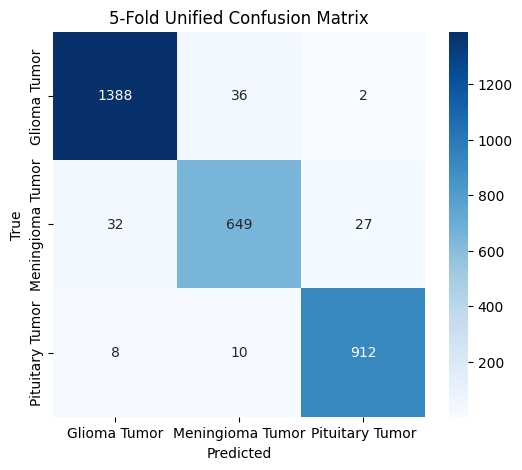

In [38]:
final_5fcv_acc = run_5_fold_cv(T=3.0, alpha=0.5)

In [39]:
# def run_5fold_grid_search(T_candidates: list[float] = [2, 3], alpha_candidates: list[float] = [0.4, 0.5, 0.6]) -> pd.DataFrame:
#     """Executes a 5-Fold Cross-Validation Grid Search for Knowledge Distillation.

#     This function performs hyperparameter tuning over specified Temperatures (T)
#     and distillation weights (Alpha). It first extracts and caches the soft 
#     labels from the teacher ensemble for all 5 folds to optimize performance. 
#     Then, it iteratively trains and evaluates the student model across all 
#     folds for every hyperparameter combination.

#     Args:
#         T_candidates (list[float], optional): A list of Temperature values to 
#             test for softening the teacher logits. Defaults to [2, 3].
#         alpha_candidates (list[float], optional): A list of alpha weights to 
#             balance the distillation loss and focal loss. Defaults to [0.4, 0.5, 0.6].

#     Returns:
#         pd.DataFrame: A DataFrame containing the grid search results, including 
#         the evaluated Temperature, Alpha, average 5-fold validation accuracy, 
#         and individual fold accuracies.
#     """
#     for k in range(1, 6):
#         fold_dir = os.path.join(SAVE_DIR, f'fold_{k}')
#         soft_labels_path = os.path.join(fold_dir, 'train_soft_labels.npy')
#         if not os.path.exists(soft_labels_path):
#             print(f"[*] Extracting Soft Labels for Fold {k} (Run only once)...")
#             current_model1_path = os.path.join(MODEL1_DIR, f'{MODEL1_NAME}_base_fold_{k}.pth')
#             current_model2_path = os.path.join(MODEL2_DIR, f'{MODEL2_NAME}_base_fold_{k}.pth')
#             current_model3_path = os.path.join(MODEL3_DIR, f'{MODEL3_NAME}_base_fold_{k}.pth')
            
            
#             generate_ensemble_soft_labels(
#                 k=k, 
#                 model1_path=current_model1_path,
#                 model2_path=current_model2_path,
#                 model3_path=current_model3_path,
#                 save_dir=SAVE_DIR
#             )
#         else:
#             print(f"[v] Soft labels for Fold {k} already had. *SKIP* ")

    
#     results = []
#     combinations = list(itertools.product(T_candidates, alpha_candidates))
    
#     best_overall_acc = 0.0
#     best_config = (2, 0.5)

#     for idx, (T, alpha) in enumerate(combinations):
#         print(f'[{idx + 1}/{len(combinations)}] Training with T = {T}, Alpha = {alpha}...')
        
#         fold_accuracies = []
        
#         for k in range(1, 6):
#             print(f'\n---Training on Fold {k} (T={T}, Alpha={alpha}) ---')
            
#             # Load DataLoaders
#             train_distill_loader = get_distillation_loader(k=k, save_dir=SAVE_DIR)
#             val_loader = get_valid_data_for_fold(k=k)
            
#             # to prevent overwriting the 'student_distilled.pth' of other configs.
#             config_fold_dir = os.path.join(SAVE_DIR, f'T_{T}_alpha_{alpha}', f'fold_{k}')
#             os.makedirs(config_fold_dir, exist_ok=True)
            
#             # 1. Train the student model
#             history = train_student_distillation(
#                 train_loader=train_distill_loader,
#                 val_loader=val_loader,
#                 save_dir=config_fold_dir,
#                 T=T,
#                 alpha_distill=alpha,
#             )
            
            
#             # 2. Inference 5 times 
#             print(f"\n[*] Running 5-times inference confirmation for Fold {k}...")
            
#             checkpoint_path = os.path.join(config_fold_dir, 'student_distilled.pth')
#             eval_model = build_student_model().to(device=device)
#             eval_model.load_state_dict(torch.load(checkpoint_path, weights_only=True, map_location=device))
#             criterion = SparseCategoricalFocalLoss(gamma=2.0, reduction='mean').to(device=device)
#             eval_model.eval()
            
#             runs = 5
#             run_accs = []
            
#             for i in range(1, runs + 1):
                
#                 loss, acc = test_epoch(
#                     model=eval_model,
#                     data_loader=val_loader,
#                     focal_loss_fn=criterion,
#                     epoch_idx=i,
#                     total_epochs=runs,
#                     return_preds=False
#                 )
#                 run_accs.append(acc)
#                 print(f"Run {i}: Val Accuracy = {acc*100:.4f}% | Loss = {loss:.4f}")

#             # Calculate mean
#             best_fold_acc = sum(run_accs) / float(runs)
#             fold_accuracies.append(best_fold_acc)
#             print(f'[v] Final officially verified accuracy for Fold {k} = {best_fold_acc*100:.2f}%')
            
#             # Clean up RAM
#             del train_distill_loader, val_loader, eval_model, criterion
#             torch.cuda.empty_cache()
#             gc.collect()

#         # Calculate the macro-average accuracy across all 5 folds
#         avg_acc = sum(fold_accuracies) / 5.0
#         print(f'\n=== Avg 5 fold T={T}, Alpha={alpha}: {avg_acc*100:.2f}% ===\n')

#         # Store the current configuration's performance
#         results.append({
#             'Temperature': T,
#             'Alpha': alpha,
#             'Average_Accuracy': avg_acc,
#             'Fold_Accuracies': fold_accuracies
#         })

#         # Update the best overall configuration tracking
#         if avg_acc > best_overall_acc:
#             best_overall_acc = avg_acc
#             best_config = (T, alpha)

#     print(f'Best config: T = {best_config[0]}, Alpha = {best_config[1]}')
#     print(f'Best avg 5 fold val accuracy: {best_overall_acc*100:.2f}%')
#     return pd.DataFrame(results)

In [40]:
# df_results = run_5fold_grid_search(
#     T_candidates=[2, 3], 
#     alpha_candidates=[0.4, 0.5, 0.6]
# )


# plt.figure(figsize=(8, 6))
# pivot_table = df_results.pivot(index="Temperature", columns="Alpha", values="Average_Accuracy")
# sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="RdYlGn", cbar_kws={'label': 'Average 5-Fold Val Accuracy'})

# plt.title(f"5-Fold Grid Search Results (Best Avg: {df_results['Average_Accuracy'].max()*100:.2f}%)")
# plt.xlabel("Alpha")
# plt.ylabel("Temperature")
# plt.show()


# print("\n Details of metric accuracy on each folds:")
# display(df_results)

# # Header
# md_string = "### Result of 5-Fold Cross Validation (Inference Verified)\n\n"
# md_string += "| Temperature (T) | Alpha (α) | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5 | **Mean** |\n"
# md_string += "| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |\n"


# for index, row in df_results.iterrows():
#     t_val = row['Temperature']
#     alpha_val = row['Alpha']
#     folds = row['Fold_Accuracies'] 
#     avg_val = row['Average_Accuracy']
#     f1, f2, f3, f4, f5 = [f"{acc*100:.2f}%" for acc in folds]
#     avg_str = f"**{avg_val*100:.2f}%**"
#     md_string += f"| {t_val} | {alpha_val} | {f1} | {f2} | {f3} | {f4} | {f5} | {avg_str} |\n"

# print(md_string)